### 0 - Import required packages

In [2]:
# basics
import os
import numpy as np
import pprint as pp

# pandas is used to read/process data
import pandas as pd

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import minimize
from scipy.stats import linregress
from scipy.signal import find_peaks
from scipy.signal import savgol_filter

from ydata_profiling import ProfileReport


### 1 - Import Dataset

In [3]:
# load data locally

DATA_FILE = "Data/20251120_Silicon.csv"
df = pd.read_csv(DATA_FILE)
print(f"✅ Loaded data from {DATA_FILE}, shape = {df.shape}")

✅ Loaded data from Data/20251120_Silicon.csv, shape = (210, 17)


Look at the first rows to see if everythings seems reasonable

In [4]:
df.head()

,time_s,water_b1_ml_min,water_b2_ml_min,water_b3_ml_min,water_a1_ml_min,si350_t1_ml_min,si350_t2_ml_min,si350_t3_ml_min,si1000_t1_ml_min,si1000_t2_ml_min,si1000_t3_ml_min,si5000_t1_ml_min,si5000_t2_ml_min,si5000_t3_ml_min,si12500_t1_ml_min,si12500_t2_ml_min,si12500_t3_ml_min
0,0.007,0.4326,-0.1444,0.2212,0.0666,0.0702,-0.0776,-0.0870,0.0870,0.1034,0.1002,0.0720,-0.0218,0.0454,-0.0950,0.0458,0.0700
1,0.507,0.4514,-0.1550,0.1898,0.0614,0.0654,-0.0306,-0.0708,0.0824,0.1026,0.0900,0.0712,-0.0052,0.0252,-0.0820,0.0350,0.0630
2,1.007,0.4106,0.0296,0.1964,0.0544,0.0588,0.0298,-0.0406,0.0758,0.1118,0.0822,0.0678,0.0150,-0.0200,-0.0674,0.0318,0.0794
3,1.507,0.4992,0.2690,0.1956,0.0536,0.0578,0.0634,0.0224,0.0726,0.1160,0.0778,0.0604,0.0354,-0.0376,-0.0536,0.0328,0.0802
4,2.007,0.3524,0.3612,0.1364,0.0524,-0.0926,0.0988,0.0638,0.0702,0.1162,0.0736,0.0134,0.0494,-0.0394,-0.0396,0.0384,0.0820


In [5]:
def find_flow_cycles(time, flow, min_prominence=0.01, min_distance_sec=0.5):
    """
    Find repetitive cycles in flow data by detecting gradient sign changes with low flow values.
    
    Algorithm:
    1. Check all data for each sample from beginning to end
    2. Calculate gradient (flow change) between consecutive points
    3. Find critical points where gradient sign changes AND flow value is in lowest 20%
    4. Ensure critical points are at least 8 seconds apart
    5. Label these points as cycle start/end boundaries
    
    Parameters:
    - time: array of time values (seconds)
    - flow: array of flow values (ml/min)
    - min_prominence: not used in new algorithm, kept for compatibility
    - min_distance_sec: not used (fixed at 8.0 seconds), kept for compatibility
    
    Returns:
    - cycles: list of dictionaries containing cycle information including actual data
    """
    # Remove NaN values
    valid_mask = ~np.isnan(flow)
    valid_time = time[valid_mask]
    valid_flow = flow[valid_mask]
    
    if len(valid_flow) < 10:  # Need minimum points for analysis
        return []
    
    # Calculate gradient (flow change) between consecutive points
    gradients = np.diff(valid_flow)  # gradient[i] = flow[i+1] - flow[i]
    
    if len(gradients) < 5:
        return []
    
    # Calculate 20th percentile of flow values for threshold
    flow_20th_percentile = np.percentile(valid_flow, 20)
    
    # Find critical points where gradient sign changes AND flow value is in lowest 20%
    critical_points = []
    last_critical_time = -float('inf')  # Track time of last critical point
    
    # Start from the second point (index 1) since we need gradient
    for i in range(1, len(gradients)):
        # Check if gradient sign changes
        if gradients[i-1] * gradients[i] < 0:  # Sign change detected
            
            # Check if flow rate value is in lowest 20%
            current_flow = valid_flow[i]
            current_time = valid_time[i]
            
            if current_flow <= flow_20th_percentile:
                # Check if enough time has passed since the last critical point (minimum 8 seconds)
                if current_time - last_critical_time >= 8.0:
                    critical_points.append({
                        'index': i,  # Index in valid arrays
                        'time': current_time,
                        'flow': current_flow,
                        'gradient_before': gradients[i-1],
                        'gradient_after': gradients[i],
                        'flow_threshold': flow_20th_percentile
                    })
                    last_critical_time = current_time
    
    if len(critical_points) < 2:
        return []
    
    # Create cycles from consecutive critical points
    cycles = []
    
    for i in range(len(critical_points) - 1):
        start_cp = critical_points[i]
        end_cp = critical_points[i + 1]
        
        start_idx = start_cp['index']
        end_idx = end_cp['index']
        
        # Find peak within this cycle
        cycle_flow_segment = valid_flow[start_idx:end_idx+1]
        peak_relative_idx = np.argmax(cycle_flow_segment)
        peak_idx = start_idx + peak_relative_idx
        
        # Extract cycle data (time and flow arrays for this specific cycle)
        cycle_mask = (valid_time >= start_cp['time']) & (valid_time <= end_cp['time'])
        cycle_time_data = valid_time[cycle_mask]
        cycle_flow_data = valid_flow[cycle_mask]
        
        # Calculate cycle statistics
        duration = end_cp['time'] - start_cp['time']
        amplitude = valid_flow[peak_idx] - min(start_cp['flow'], end_cp['flow'])
        
        cycle_info = {
            'cycle_number': len(cycles) + 1,
            'start_time': start_cp['time'],
            'peak_time': valid_time[peak_idx],
            'end_time': end_cp['time'],
            'start_idx': start_idx,
            'peak_idx': peak_idx,
            'end_idx': end_idx,
            'duration': duration,
            'start_flow': start_cp['flow'],
            'peak_flow': valid_flow[peak_idx],
            'end_flow': end_cp['flow'],
            'amplitude': amplitude,
            # Cycle data arrays
            'cycle_time': cycle_time_data.copy(),  # Time array for this cycle
            'cycle_flow': cycle_flow_data.copy(),  # Flow array for this cycle
            'data_points': len(cycle_time_data),   # Number of data points in cycle
            # New gradient-based information
            'start_gradient_change': (start_cp['gradient_before'], start_cp['gradient_after']),
            'end_gradient_change': (end_cp['gradient_before'], end_cp['gradient_after']),
            'start_flow_value': start_cp['flow'],
            'end_flow_value': end_cp['flow'],
            'flow_threshold': flow_20th_percentile
        }
        cycles.append(cycle_info)
    
    return cycles

In [6]:
# Define all flow columns in the dataset
all_flow_columns = [
    'water_b1_ml_min', 'water_b2_ml_min', 'water_b3_ml_min',
    'si350_t1_ml_min', 'si350_t2_ml_min', 'si350_t3_ml_min',
    'si1000_t1_ml_min', 'si1000_t2_ml_min', 'si1000_t3_ml_min',
    'si5000_t1_ml_min', 'si5000_t2_ml_min', 'si5000_t3_ml_min',
    'si12500_t1_ml_min', 'si12500_t2_ml_min', 'si12500_t3_ml_min',
    'water_a1_ml_min'
]

# Get time data
time_data = df['time_s'].values

# Analyze each sample
cycle_summary = []

for sample_col in all_flow_columns:
   
    flow_data = df[sample_col].values
        
    # Run find_flow_cycles
    cycles = find_flow_cycles(time_data, flow_data)
    # Calculate statistics
    durations = [c['duration'] for c in cycles]
    amplitudes = [c['amplitude'] for c in cycles]
    peak_flows = [c['peak_flow'] for c in cycles]
    total_data_points = sum([c['data_points'] for c in cycles])
            
    cycle_summary.append({
        'Sample': sample_col,
        'Cycles_Detected': len(cycles),
        'Avg_Duration_s': np.mean(durations),
        'Std_Duration_s': np.std(durations),
    })

# Create summary DataFrame
cycle_summary_df = pd.DataFrame(cycle_summary)

# Display the summary table
cycle_summary_df

,Sample,Cycles_Detected,Avg_Duration_s,Std_Duration_s
0,water_b1_ml_min,6,14.503333,0.288708
1,water_b2_ml_min,7,14.360000,0.789206
2,water_b3_ml_min,6,14.836667,0.553183
3,si350_t1_ml_min,6,14.670000,0.236896
4,si350_t2_ml_min,6,14.586333,0.186812
5,si350_t3_ml_min,6,14.753000,0.250023
6,si1000_t1_ml_min,6,14.586667,0.345472
7,si1000_t2_ml_min,6,14.586500,0.184967
8,si1000_t3_ml_min,6,14.586667,0.190222
9,si5000_t1_ml_min,5,17.604000,5.702422


In [7]:
def get_cycle_data(sample_column, cycle_number, df=df, time=None):
    """
    Retrieve the time and flow data for a specific cycle of a specific sample.
    
    Parameters:
    - sample_column: string, column name in DataFrame (e.g., 'water_b1_ml_min')
    - cycle_number: int, cycle number (1-indexed)
    - df: DataFrame containing the data
    - time: time array (if None, uses df['time_s'])
    
    Returns:
    - dict with cycle info including time and flow arrays, or None if not found
    """
    if time is None:
        time = df['time_s'].values
    
    if sample_column not in df.columns:
        print(f"Error: Column '{sample_column}' not found in DataFrame")
        return None
    
    flow_data = df[sample_column].values
    
    # Find all cycles for this sample
    cycles = find_flow_cycles(time, flow_data, min_prominence=0.01, min_distance_sec=0.5)
    
    if cycle_number < 1 or cycle_number > len(cycles):
        print(f"Error: Cycle {cycle_number} not found. Sample '{sample_column}' has {len(cycles)} cycles.")
        return None
    
    # Return the requested cycle (convert to 0-indexed)
    return cycles[cycle_number - 1]

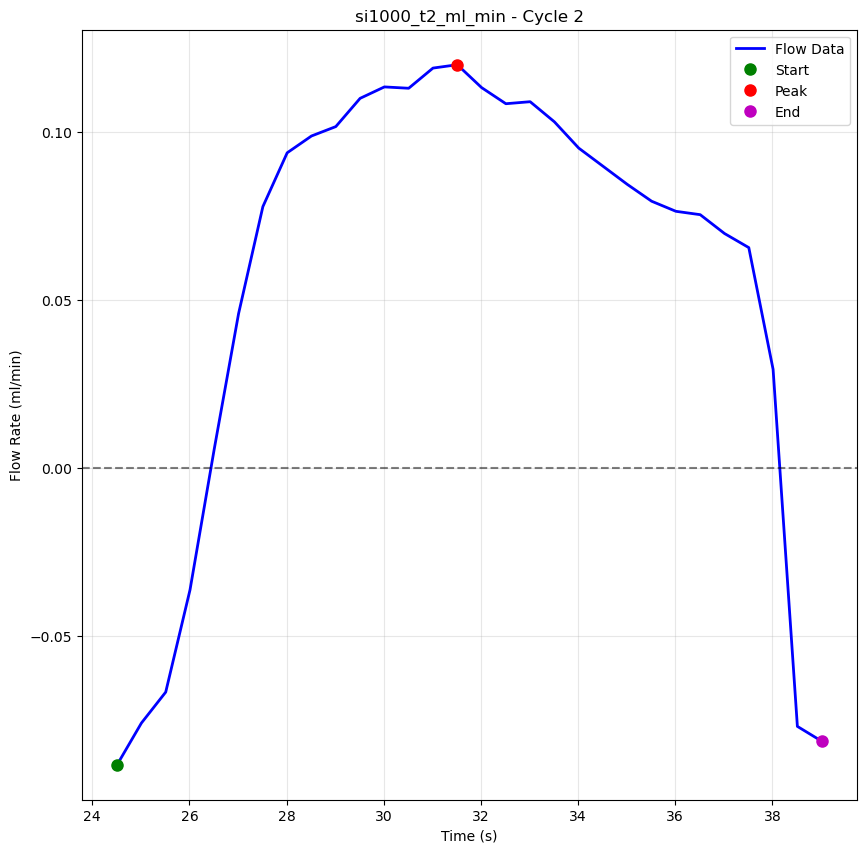

In [8]:
# Simple example: Get and plot a single cycle
#sample_name = 'water_b1_ml_min'
sample_name = 'si1000_t2_ml_min'
cycle_number = 2

# Get cycle data
cycle_data = get_cycle_data(sample_name, cycle_number)

# Plot the cycle
plt.figure(figsize=(10, 10))
plt.plot(cycle_data['cycle_time'], cycle_data['cycle_flow'], 'b-', linewidth=2, label='Flow Data')
   
# Mark start, peak, and end points
plt.plot(cycle_data['start_time'], cycle_data['start_flow'], 'go', markersize=8, label='Start')
plt.plot(cycle_data['peak_time'], cycle_data['peak_flow'], 'ro', markersize=8, label='Peak')
plt.plot(cycle_data['end_time'], cycle_data['end_flow'], 'mo', markersize=8, label='End')
  
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Flow Rate (ml/min)')
plt.title(f'{sample_name} - Cycle {cycle_number}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
def apply_savitzky_filter(cycle_data, window_length=5, polyorder=3):
    """
    Apply Savitzky-Golay filter to smooth cycle data and identify segment boundaries.
    
    Parameters:
    - cycle_data: dict from get_cycle_data() containing cycle information
    - window_length: int, window length for Savitzky-Golay filter (must be odd)
    - polyorder: int, polynomial order for Savitzky-Golay filter
    
    Returns:
    - dict with smoothed data and segment boundaries
    """
    if cycle_data is None:
        print("No cycle data provided")
        return None
    
    # Extract cycle time and flow data
    time_orig = cycle_data['cycle_time']
    flow_orig = cycle_data['cycle_flow']
    
    if len(time_orig) < window_length:
        print(f"Insufficient data points ({len(time_orig)}) for filtering (need >= {window_length})")
        return None
    
    # Apply Savitzky-Golay filter to smooth the data
    flow_smooth = savgol_filter(flow_orig, window_length, polyorder)
    
    # Calculate derivatives to identify change points
    dt = np.diff(time_orig)
    dy_smooth = np.diff(flow_smooth)
    slope = dy_smooth / np.maximum(dt, 1e-12)
    
    # Smooth the slope as well for better change point detection
    if len(slope) >= window_length:
        slope_smooth = savgol_filter(slope, window_length, polyorder)
    else:
        slope_smooth = slope
    
    # Find critical points for 4-line segmentation based on revised specifications
    n_points = len(time_orig)
    
    # Define temporal boundaries for constraints
    quarter_point = n_points // 4          # 25% of cycle
    three_quarter_point = 3 * n_points // 4  # 75% of cycle
    
    # B2: Find the peak (maximum flow) between 25% and 75% of cycle
    # Search for peak in the middle 50% of the cycle
    peak_search_start = quarter_point
    peak_search_end = three_quarter_point
    
    if peak_search_end <= peak_search_start:
        # Fallback if data is too short
        peak_search_start = max(1, n_points // 3)
        peak_search_end = min(n_points - 2, 2 * n_points // 3)
    
    # Find peak (maximum) in smoothed flow data
    peak_region_flow = flow_smooth[peak_search_start:peak_search_end]
    if len(peak_region_flow) > 0:
        peak_local_idx = np.argmax(peak_region_flow)
        seg2_end = peak_search_start + peak_local_idx  # B2 = peak
    else:
        seg2_end = n_points // 2  # Fallback to middle
    
    # B1: Find where gradient loses its huge value (before 25% of cycle)
    # Look for significant decrease in slope magnitude in first quarter
    def find_gradient_loss(search_end_idx, slope_data):
        """Find where gradient loses its huge initial value"""
        if search_end_idx < 3:
            return search_end_idx // 2
        
        # Calculate slope magnitude (absolute value)
        slope_magnitude = np.abs(slope_data[:search_end_idx-1])
        
        if len(slope_magnitude) < 3:
            return search_end_idx // 2
        
        # Find where slope magnitude drops significantly from its initial high value
        # Look for the point where slope drops to 50% of initial maximum
        initial_max_slope = np.max(slope_magnitude[:min(3, len(slope_magnitude))])
        threshold = initial_max_slope * 0.5
        
        # Find first point where slope drops below threshold
        drop_indices = np.where(slope_magnitude < threshold)[0]
        if len(drop_indices) > 0:
            return min(drop_indices[0] + 1, search_end_idx - 1)
        else:
            # If no significant drop found, use 1/3 of the search region
            return max(1, search_end_idx // 3)
    
    seg1_end = find_gradient_loss(quarter_point, slope_smooth)
    
    # B3: Find where gradient changes significantly (after 75% of cycle)
    # Look for significant change in gradient value in last quarter
    def find_gradient_change(search_start_idx, slope_data):
        """Find where gradient value changes significantly in the final phase"""
        if search_start_idx >= len(slope_data) - 2:
            return len(slope_data) - 1
        
        # Get slope values in the last quarter
        slope_segment = slope_data[search_start_idx:]
        
        if len(slope_segment) < 3:
            return min(search_start_idx + 1, len(slope_data) - 1)
        
        # Calculate gradient changes (second derivative)
        gradient_changes = np.abs(np.diff(slope_segment))
        
        if len(gradient_changes) == 0:
            return search_start_idx + len(slope_segment) // 2
        
        # Find the point with maximum gradient change
        max_change_idx = np.argmax(gradient_changes)
        
        # Also check for threshold-based detection
        # Use median of gradient changes as baseline
        change_threshold = np.median(gradient_changes) * 2.0
        
        # Find first significant change above threshold
        significant_changes = np.where(gradient_changes > change_threshold)[0]
        
        if len(significant_changes) > 0:
            # Use the first significant change, but prefer it to be closer to max change
            first_sig_change = significant_changes[0]
            # If max change is within 3 points of first significant change, use max
            if abs(max_change_idx - first_sig_change) <= 3:
                return search_start_idx + max_change_idx + 1
            else:
                return search_start_idx + first_sig_change + 1
        else:
            # If no threshold crossings, use maximum change point
            return search_start_idx + max_change_idx + 1
    
    seg3_end = find_gradient_change(three_quarter_point, slope_smooth)
    
    # Ensure boundaries are in order and valid with revised constraints
    # B1 must be in first 25% of cycle
    seg1_end = max(1, min(seg1_end, quarter_point))
    
    # B2 (peak) must be between B1 and 75% of cycle, and after 25%  
    seg2_end = max(seg1_end + 1, min(seg2_end, three_quarter_point))
    seg2_end = max(quarter_point, seg2_end)  # Ensure B2 is after first 25%
    
    # B3 must be after 75% of cycle and after B2
    seg3_end = max(seg2_end + 1, min(seg3_end, n_points - 1))
    seg3_end = max(three_quarter_point, seg3_end)  # Ensure B3 is after last 25%
    
    # Define segment boundaries with revised specifications:
    # B1: Where gradient loses huge value (< 25% of cycle)
    # B2: Peak of cycle (between 25% and 75% of cycle) 
    # B3: Where gradient value changes significantly (> 75% of cycle)
    boundaries = {
        'seg1_end': seg1_end,    # B1: End of sharp increase phase
        'seg2_end': seg2_end,    # B2: Peak (end of gradual increase phase)
        'seg3_end': seg3_end,    # B3: Where gradient changes significantly 
        'n_points': n_points
    }
    
    return {
        'time_orig': time_orig,
        'flow_orig': flow_orig,
        'flow_smooth': flow_smooth,
        'boundaries': boundaries,
        'smoothing_params': {
            'window_length': window_length,
            'polyorder': polyorder
        },
        'cycle_data': cycle_data
    }

In [10]:
def fit_segments_to_cycle(filtered_data, plot=True):
    """
    Fit polynomial segments to cycle data with different orders for each segment:
    1. Segment 1: From cycle start to 3 seconds - 1st order (linear)
    2. Segment 2: From 3 seconds to peak - 2nd order (quadratic, concave down)  
    3. Segment 3: From peak to 3 seconds before end - 2nd order (quadratic, no concavity constraint)
    4. Segment 4: From 3 seconds before end to cycle end - 1st order (linear)
    
    Parameters:
    - filtered_data: dict from apply_savitzky_filter() containing smoothed data
    - plot: bool, whether to create visualization
    
    Returns:
    - dict with fitted segments and statistics
    """
    if filtered_data is None:
        print("No filtered data provided")
        return None
    
    time_orig = filtered_data['time_orig']
    flow_orig = filtered_data['flow_orig']
    flow_smooth = filtered_data['flow_smooth']
    
    # Calculate time-based boundaries
    cycle_duration = time_orig[-1] - time_orig[0]
    
    # Find indices for time-based boundaries
    def find_time_index(target_time):
        """Find the index closest to the target time"""
        return np.argmin(np.abs(time_orig - target_time))
    
    # Segment boundaries based on time
    seg1_end_time = time_orig[0] + 1.5  # 1.5 seconds from start
    seg4_start_time = time_orig[-1] - 1.5  # 1.5 seconds before end
    
    # Find peak (maximum flow) in the data
    peak_idx = np.argmax(flow_smooth)
    peak_time = time_orig[peak_idx]
    
    # Convert times to indices
    seg1_end_idx = find_time_index(seg1_end_time)
    seg4_start_idx = find_time_index(seg4_start_time)
    
    # Ensure peak is between seg1_end and seg4_start
    if peak_idx <= seg1_end_idx:
        # If peak is too early, extend segment 1 to just before peak
        seg1_end_idx = max(1, peak_idx - 1)
    elif peak_idx >= seg4_start_idx:
        # If peak is too late, move segment 4 start to just after peak
        seg4_start_idx = min(len(time_orig) - 2, peak_idx + 1)
    
    # Segment boundaries
    seg2_end_idx = peak_idx  # Segment 2 ends at peak
    seg3_end_idx = seg4_start_idx  # Segment 3 ends where segment 4 starts
    
    # Define the 4 segments with their polynomial orders
    segments = {
        'line1': {  # Start to 3 seconds - 1st order (linear)
            'start_idx': 0,
            'end_idx': seg1_end_idx,
            'name': 'Initial Ramp (0-3s)',
            'color': 'red',
            'poly_order': 1
        },
        'line2': {  # 3 seconds to peak - 2nd order (quadratic)
            'start_idx': seg1_end_idx,
            'end_idx': seg2_end_idx,
            'name': 'Rise to Peak (3s-peak)', 
            'color': 'orange',
            'poly_order': 2
        },
        'line3': {  # Peak to 3 seconds before end - 2nd order (quadratic)
            'start_idx': seg2_end_idx,
            'end_idx': seg3_end_idx,
            'name': 'Peak to Final (peak-3s)',
            'color': 'green',
            'poly_order': 2
        },
        'line4': {  # 3 seconds before end to end - 1st order (linear)
            'start_idx': seg3_end_idx,
            'end_idx': len(time_orig) - 1,
            'name': 'Final Descent (3s-end)',
            'color': 'purple',
            'poly_order': 1
        }
    }
    
    # Fit polynomials to each segment
    for line_name, seg in segments.items():
        start_idx = seg['start_idx']
        end_idx = seg['end_idx']
        poly_order = seg['poly_order']
        
        if end_idx <= start_idx:
            continue
            
        # Get segment data
        t_seg = time_orig[start_idx:end_idx+1]
        y_seg = flow_smooth[start_idx:end_idx+1]  # Use smoothed data for fitting
        
        if len(t_seg) >= poly_order + 1:  # Need at least poly_order+1 points
            # Polynomial fitting
            if poly_order == 2:
                # For quadratic segments
                poly_coeffs = np.polyfit(t_seg, y_seg, poly_order)
                
                # Apply concavity constraints only for segment 2 (gradual increase)
                if line_name == 'line2':  # Rise to peak - should be concave down
                    if poly_coeffs[0] > 0:  # If concave up, force concave down
                        poly_coeffs[0] = -abs(poly_coeffs[0]) * 0.1  # Small negative curvature
                # For line3 (segment 3), no concavity constraint is applied
                        
                poly_func = np.poly1d(poly_coeffs)
            else:
                # Standard polynomial fitting for linear segments
                poly_coeffs = np.polyfit(t_seg, y_seg, poly_order)
                poly_func = np.poly1d(poly_coeffs)
            
            # Calculate R-squared
            y_pred = poly_func(t_seg)
            ss_res = np.sum((y_seg - y_pred) ** 2)
            ss_tot = np.sum((y_seg - np.mean(y_seg)) ** 2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
            
            # For linear segments, also calculate slope
            if poly_order == 1:
                slope_val = poly_coeffs[0]  # First coefficient is slope
                intercept = poly_coeffs[1]   # Second coefficient is intercept
            else:
                # For quadratic segments, calculate average slope
                slope_val = (y_seg[-1] - y_seg[0]) / (t_seg[-1] - t_seg[0]) if len(t_seg) > 1 else 0
                intercept = np.nan
            
            # Store segment information
            seg.update({
                'start_time': time_orig[start_idx],
                'end_time': time_orig[end_idx],
                'start_flow': flow_orig[start_idx],
                'end_flow': flow_orig[end_idx],
                'start_flow_smooth': flow_smooth[start_idx],
                'end_flow_smooth': flow_smooth[end_idx],
                'poly_coeffs': poly_coeffs,
                'poly_func': poly_func,
                'slope': slope_val,
                'intercept': intercept,
                'r_squared': r_squared,
                'duration': time_orig[end_idx] - time_orig[start_idx],
                'data_points': end_idx - start_idx + 1
            })
        else:
            # Handle degenerate case
            seg.update({
                'start_time': time_orig[start_idx],
                'end_time': time_orig[end_idx] if end_idx < len(time_orig) else time_orig[start_idx],
                'start_flow': flow_orig[start_idx],
                'end_flow': flow_orig[end_idx] if end_idx < len(flow_orig) else flow_orig[start_idx],
                'poly_coeffs': [0],
                'poly_func': None,
                'slope': 0,
                'intercept': flow_orig[start_idx],
                'r_squared': 0,
                'duration': 0,
                'data_points': 1
            })
    
    # Create visualization if requested
    if plot:
        plt.figure(figsize=(14, 10))
        
        # Plot original data
        plt.plot(time_orig, flow_orig, 'b-', alpha=0.6, linewidth=1, label='Original Data')
        
        # Plot smoothed data
        plt.plot(time_orig, flow_smooth, 'k-', linewidth=2, label='Savitzky-Golay Smoothed')
        
        # Plot each fitted segment
        for line_name, seg in segments.items():
            if 'poly_func' in seg and seg['poly_func'] is not None:
                start_idx = seg['start_idx']
                end_idx = seg['end_idx']
                t_seg = time_orig[start_idx:end_idx+1]
                
                # Generate smooth curve for plotting
                t_plot = np.linspace(t_seg[0], t_seg[-1], 100)
                y_plot = seg['poly_func'](t_plot)
                
                if seg['poly_order'] == 1:
                    order_text = f"(linear)"
                elif seg['poly_order'] == 2:
                    if line_name == 'line2':
                        concavity = "concave down"
                    elif line_name == 'line3':
                        concavity = "no constraint"
                    else:
                        concavity = ""
                    order_text = f"(quadratic, {concavity})" if concavity else "(quadratic)"
                else:
                    order_text = f"({seg['poly_order']}rd order)"
                plt.plot(t_plot, y_plot, color=seg['color'], linewidth=3, 
                        label=f"{seg['name']} {order_text} (R²={seg['r_squared']:.3f})")
        
        # Mark segment boundaries
        boundary_times = [segments['line1']['end_time'], 
                         segments['line2']['end_time'], 
                         segments['line3']['end_time']]
        boundary_labels = ['3s', 'Peak', '3s before end']
        
        for i, (t_boundary, label) in enumerate(zip(boundary_times, boundary_labels)):
            plt.axvline(x=t_boundary, color='gray', linestyle='--', alpha=0.7)
            plt.text(t_boundary, plt.ylim()[1] * (0.9 - i*0.05), label, 
                    ha='center', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
        plt.xlabel('Time (s)')
        plt.ylabel('Flow Rate (ml/min)')
        
        # Get smoothing parameters for title
        smooth_params = filtered_data['smoothing_params']
        plt.title(f'4-Segment Cycle Analysis with Time-Based Boundaries\n'
                 f'Savitzky-Golay Filter (window={smooth_params["window_length"]}, order={smooth_params["polyorder"]})\n'
                 f'Seg1: 0→3s (linear), Seg2: 3s→peak (quad), Seg3: peak→3s-end (quad), Seg4: 3s-end→end (linear)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # Calculate overall statistics
    cycle_data = filtered_data['cycle_data']
    total_duration = cycle_data['duration']
    line_durations = [seg['duration'] for seg in segments.values() if 'duration' in seg]
    line_slopes = [seg['slope'] for seg in segments.values() if 'slope' in seg and not np.isnan(seg['slope'])]
    line_r_squared = [seg['r_squared'] for seg in segments.values() if 'r_squared' in seg]
    
    # Add boundary information to results
    boundaries = {
        'seg1_end': seg1_end_idx,    # 3 seconds from start
        'seg2_end': seg2_end_idx,    # Peak
        'seg3_end': seg3_end_idx,    # 3 seconds before end
        'n_points': len(time_orig),
        'peak_time': peak_time,
        'cycle_duration': cycle_duration
    }
    
    result = {
        'segments': segments,
        'filtered_data': filtered_data,
        'boundaries': boundaries,
        'statistics': {
            'total_duration': total_duration,
            'line_durations': line_durations,
            'line_slopes': line_slopes,
            'mean_r_squared': np.mean(line_r_squared) if line_r_squared else 0,
            'slope_range': np.max(line_slopes) - np.min(line_slopes) if line_slopes else 0
        },
        'cycle_info': cycle_data
    }
    
    return result

Analyzing water_b1_ml_min, cycle 3
✓ Cycle data retrieved: 31 data points
  Duration: 15.00 seconds
  Flow range: -1.4888 to 0.4902 ml/min

🔧 Applying Savitzky-Golay filtering...
✓ Filtering completed
  Segment boundaries: 2, 13, 29

📊 Fitting polynomial segments...


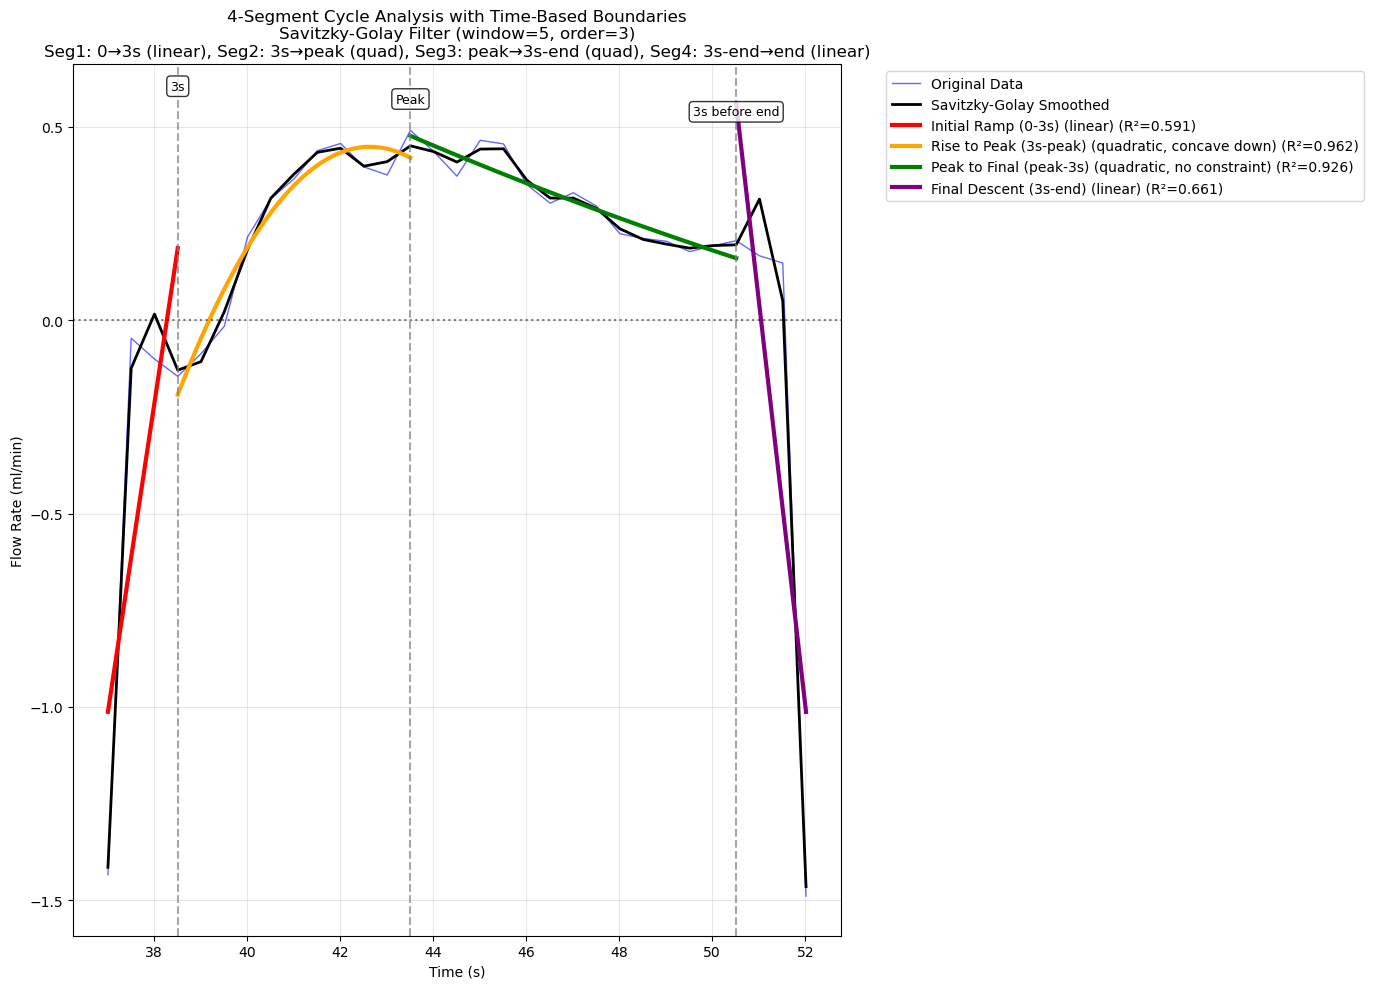

✓ Segment fitting completed

SIMULATION RESULTS

Initial Ramp (0-3s) (1st order polynomial):
  Time: 37.01 → 38.51 s (duration: 1.50s)
  Flow: -1.4338 → -0.1454 ml/min
  Slope: 0.7989 ml/min/s
  R²: 0.5910
  Data points: 4

Rise to Peak (3s-peak) (2rd order polynomial):
  Time: 38.51 → 43.51 s (duration: 5.00s)
  Flow: -0.1454 → 0.4902 ml/min
  Slope: 0.1160 ml/min/s
  R²: 0.9623
  Data points: 11

Peak to Final (peak-3s) (2rd order polynomial):
  Time: 43.51 → 50.51 s (duration: 7.00s)
  Flow: 0.4902 → 0.2050 ml/min
  Slope: -0.0365 ml/min/s
  R²: 0.9255
  Data points: 15

Final Descent (3s-end) (1st order polynomial):
  Time: 50.51 → 52.01 s (duration: 1.50s)
  Flow: 0.2050 → -1.4888 ml/min
  Slope: -1.0479 ml/min/s
  R²: 0.6610
  Data points: 4

Overall Statistics:
  Mean R²: 0.7850
  Slope range: 1.8468 ml/min/s
  Total duration: 15.00 s
  Line durations: ['1.50s', '5.00s', '7.00s', '1.50s']

🎯 Analysis complete!


In [11]:
# Example: Analyze a single cycle with the two new functions

# Select a sample and cycle to analyze
#sample_name = 'si350_t2_ml_min'
#sample_name = 'si1000_t2_ml_min'
sample_name = 'water_b1_ml_min'
cycle_number = 3

print(f"Analyzing {sample_name}, cycle {cycle_number}")
print("="*50)

# Step 1: Get cycle data
cycle_data = get_cycle_data(sample_name, cycle_number)

if cycle_data is None:
    print("Could not retrieve cycle data")
else:
    print(f"✓ Cycle data retrieved: {len(cycle_data['cycle_time'])} data points")
    print(f"  Duration: {cycle_data['duration']:.2f} seconds")
    print(f"  Flow range: {min(cycle_data['cycle_flow']):.4f} to {max(cycle_data['cycle_flow']):.4f} ml/min")
    
    # Step 2: Apply Savitzky-Golay filtering 
    print("\n🔧 Applying Savitzky-Golay filtering...")
    filtered_data = apply_savitzky_filter(cycle_data, window_length=5, polyorder=3)
    
    if filtered_data is None:
        print("Filtering failed")
    else:
        print("✓ Filtering completed")
        boundaries = filtered_data['boundaries']
        print(f"  Segment boundaries: {boundaries['seg1_end']}, {boundaries['seg2_end']}, {boundaries['seg3_end']}")
        
        # Step 3: Fit polynomial segments
        print("\n📊 Fitting polynomial segments...")
        simulation_result = fit_segments_to_cycle(filtered_data, plot=True)
        
        if simulation_result is None:
            print("Segment fitting failed")
        else:
            print("✓ Segment fitting completed")
            print("\n" + "="*60)
            print("SIMULATION RESULTS")
            print("="*60)
            
            # Display detailed results for each segment
            for line_name, seg in simulation_result['segments'].items():
                print(f"\n{seg['name']} ({seg['poly_order']}{'st' if seg['poly_order']==1 else 'rd'} order polynomial):")
                print(f"  Time: {seg['start_time']:.2f} → {seg['end_time']:.2f} s (duration: {seg['duration']:.2f}s)")
                print(f"  Flow: {seg['start_flow']:.4f} → {seg['end_flow']:.4f} ml/min")
                print(f"  Slope: {seg['slope']:.4f} ml/min/s")
                print(f"  R²: {seg['r_squared']:.4f}")
                print(f"  Data points: {seg['data_points']}")
            
            # Display overall statistics
            print(f"\nOverall Statistics:")
            stats = simulation_result['statistics']
            print(f"  Mean R²: {stats['mean_r_squared']:.4f}")
            print(f"  Slope range: {stats['slope_range']:.4f} ml/min/s")
            print(f"  Total duration: {stats['total_duration']:.2f} s")
            print(f"  Line durations: {[f'{d:.2f}s' for d in stats['line_durations']]}")
            
            print("\n🎯 Analysis complete!")

In [ ]:
def extract_cycle_features_for_sample(sample_name):
    """
    Extract features from all cycles of a given sample using fit_segments_to_cycle.
    
    Parameters:
    - sample_name: str, name of the sample column (e.g., 'water_b1_ml_min')
    
    Returns:
    - pandas.DataFrame with features for each cycle
    """
    # Get sample data
    if sample_name not in df.columns:
        return pd.DataFrame()
    
    # Get time and flow data
    time_data = df['time_s'].values
    flow_data = df[sample_name].values
    
    # Find cycles for this sample
    cycles = find_flow_cycles(time_data, flow_data)
    
    # Initialize list to store features
    features_list = []
    
    for cycle_idx, cycle in enumerate(cycles):
        cycle_number = cycle_idx + 1
        
        # Get cycle data
        cycle_data = get_cycle_data(sample_name, cycle_number)
        
        if cycle_data is None:
            continue
            
        # Apply Savitzky-Golay filtering
        filtered_data = apply_savitzky_filter(cycle_data, window_length=5, polyorder=3)
        
        if filtered_data is None:
            continue
            
        # Fit polynomial segments
        simulation_result = fit_segments_to_cycle(filtered_data, plot=False)
        
        if simulation_result is None:
            continue
            
        # Extract features
        segments = simulation_result['segments']
        
        # Initialize feature dict
        features = {
            'cycle_number': cycle_number
        }
        
        # Line 1 features (linear)
        if 'line1' in segments and segments['line1']['poly_func'] is not None:
            line1 = segments['line1']
            features['line1_slope'] = line1['slope']
            features['line1_intercept'] = line1['intercept']
        else:
            features['line1_slope'] = np.nan
            features['line1_intercept'] = np.nan
            
        # Line 2 features (quadratic)
        if 'line2' in segments and segments['line2']['poly_func'] is not None:
            line2 = segments['line2']
            coeffs = line2['poly_coeffs']
            features['line2_quad_coeff'] = coeffs[0] if len(coeffs) > 0 else np.nan  # quadratic term
            features['line2_line_coeff'] = coeffs[1] if len(coeffs) > 1 else np.nan  # linear term
            features['line2_const_coeff'] = coeffs[2] if len(coeffs) > 2 else np.nan  # constant term
        else:
            features['line2_quad_coeff'] = np.nan
            features['line2_line_coeff'] = np.nan
            features['line2_const_coeff'] = np.nan
            
        # Line 3 features (quadratic)
        if 'line3' in segments and segments['line3']['poly_func'] is not None:
            line3 = segments['line3']
            coeffs = line3['poly_coeffs']
            features['line3_quad_coeff'] = coeffs[0] if len(coeffs) > 0 else np.nan  # quadratic term
            features['line3_line_coeff'] = coeffs[1] if len(coeffs) > 1 else np.nan  # linear term
            features['line3_const_coeff'] = coeffs[2] if len(coeffs) > 2 else np.nan  # constant term
        else:
            features['line3_quad_coeff'] = np.nan
            features['line3_line_coeff'] = np.nan
            features['line3_const_coeff'] = np.nan
            
        # Line 4 features (linear)
        if 'line4' in segments and segments['line4']['poly_func'] is not None:
            line4 = segments['line4']
            features['line4_slope'] = line4['slope']
            features['line4_intercept'] = line4['intercept']
        else:
            features['line4_slope'] = np.nan
            features['line4_intercept'] = np.nan
            
        # Peak features
        flow_smooth = filtered_data['flow_smooth']
        features['max_peak'] = np.max(flow_smooth)
        features['min_peak'] = np.min(flow_smooth)
        
        # Time durations for each line
        features['time_line1'] = segments['line1']['duration'] if 'line1' in segments else np.nan
        features['time_line2'] = segments['line2']['duration'] if 'line2' in segments else np.nan
        features['time_line3'] = segments['line3']['duration'] if 'line3' in segments else np.nan
        features['time_line4'] = segments['line4']['duration'] if 'line4' in segments else np.nan
        
        features_list.append(features)
    
    # Convert to DataFrame
    if features_list:
        dataset = pd.DataFrame(features_list)
        
        # Add viscosity feature based on sample_name
        name_parts = sample_name.replace('_ml_min', '').split('_')
        material = name_parts[0] if name_parts else sample_name.replace('_ml_min', '')
        
        viscosity_mapping = {
            'water': 1,
            'si350': 350,
            'si1000': 1000,
            'si5000': 5000,
            'si12500': 12500
        }
        
        dataset['viscosity_cp'] = viscosity_mapping.get(material, None)
        
        return dataset
    else:
        return pd.DataFrame()


def create_datasets_for_all_samples():
    """
    Create feature datasets for all samples in the data.
    
    Returns:
    - dict with sample names as keys and DataFrames as values
    """
    # Get all flow columns (sample names)
    flow_columns = [col for col in df.columns if 'ml_min' in col and col != 'time_s']
    
    datasets = {}
    
    for sample_name in flow_columns:
        dataset = extract_cycle_features_for_sample(sample_name)
        if not dataset.empty:
            datasets[sample_name] = dataset
    
    return datasets

In [13]:
# Create datasets for all samples and integrate them
all_datasets = create_datasets_for_all_samples()

# Integrate all datasets into a single DataFrame with sample name and trial information
integrated_data = []

for sample_name, dataset in all_datasets.items():
    if not dataset.empty:
        # Parse sample name to extract material and trial
        # Expected format: material_trial_ml_min (e.g., water_b1_ml_min, si350_t2_ml_min)
        name_parts = sample_name.replace('_ml_min', '').split('_')
        
        if len(name_parts) >= 2:
            material = name_parts[0]  # water, si350, si1000, si5000, si12500
            trial = name_parts[1]     # b1, b2, b3, a1 for water; t1, t2, t3 for silicons
        else:
            material = sample_name.replace('_ml_min', '')
            trial = 'unknown'
        
        # Add sample and trial columns to dataset
        dataset_copy = dataset.copy()
        dataset_copy['sample_name'] = material
        dataset_copy['trial'] = trial
        
        integrated_data.append(dataset_copy)

# Combine all datasets
if integrated_data:
    final_dataset = pd.concat(integrated_data, ignore_index=True)
    
    # Reorder columns to have sample_name and trial at the beginning
    cols = ['sample_name', 'trial', 'cycle_number'] + [col for col in final_dataset.columns 
                                                       if col not in ['sample_name', 'trial', 'cycle_number']]
    final_dataset = final_dataset[cols]
    
else:
    final_dataset = pd.DataFrame()

In [20]:
final_dataset

,sample_name,trial,cycle_number,line1_slope,line1_intercept,line2_quad_coeff,line2_line_coeff,line2_const_coeff,line3_quad_coeff,line3_line_coeff,line3_const_coeff,line4_slope,line4_intercept,max_peak,min_peak,time_line1,time_line2,time_line3,time_line4
0,water,b1,1,0.416186,-3.900603,-0.026860,0.753282,-4.802118,0.009393,-0.396239,4.356617,-0.913308,19.694782,0.478354,-1.266337,1.5,6.002,5.500,1.504
1,water,b1,2,0.705039,-16.788775,-0.033167,1.870909,-25.926704,0.005771,-0.428872,8.132604,-1.001511,36.111418,0.483577,-1.410606,1.5,5.501,6.000,1.500
2,water,b1,3,0.798883,-30.582304,-0.037604,3.207074,-67.931290,0.000865,-0.126517,4.343275,-1.047886,53.491935,0.450223,-1.464363,1.5,5.000,7.000,1.500
3,water,b1,4,0.843413,-44.936475,-0.032449,3.741748,-107.399807,0.005456,-0.729155,24.513616,-0.858300,56.279252,0.477880,-1.476057,1.5,5.500,6.001,1.500
4,water,b1,5,0.656114,-44.500865,-0.035097,5.067277,-182.437161,0.006065,-0.979109,39.694847,-0.884725,70.874595,0.485491,-1.212923,1.5,5.503,6.009,1.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,si12500,t3,2,0.009385,-0.189182,-0.000855,0.056032,-0.822451,-0.001900,0.125286,-1.971060,-0.013353,0.547908,0.093777,0.036457,1.5,6.001,5.500,1.500
94,si12500,t3,3,0.008761,-0.301830,-0.001076,0.099747,-2.220337,-0.003490,0.338279,-8.102514,-0.014633,0.809773,0.093634,0.036369,1.5,7.500,4.000,1.500
95,si12500,t3,4,0.008827,-0.432228,-0.000954,0.117072,-3.499400,-0.002352,0.294303,-9.110120,-0.017302,1.200886,0.094874,0.036140,1.5,7.000,4.501,1.500
96,si12500,t3,5,0.007124,-0.446026,-0.000797,0.122658,-4.625237,-0.001433,0.219819,-8.337816,-0.021830,1.824698,0.094086,0.035951,1.5,6.504,5.008,1.500


In [21]:
# Add viscosity feature to the dataset
def add_viscosity_to_dataset(dataset):
    """
    Add viscosity_cp column to dataset based on sample_name.
    
    Parameters:
    - dataset: pandas DataFrame with sample_name column
    
    Returns:
    - pandas DataFrame with added viscosity_cp column
    """
    # Create a copy to avoid modifying the original
    dataset_with_viscosity = dataset.copy()
    
    # Define viscosity mapping based on sample names
    viscosity_mapping = {
        'water': 1,
        'si350': 350,
        'si1000': 1000,
        'si5000': 5000,
        'si12500': 12500
    }
    
    # Map sample_name to viscosity_cp
    dataset_with_viscosity['viscosity_cp'] = dataset_with_viscosity['sample_name'].map(viscosity_mapping)
    
    # Handle any unmapped values (should not occur with current data)
    if dataset_with_viscosity['viscosity_cp'].isna().any():
        print("Warning: Some sample_name values could not be mapped to viscosity:")
        unmapped = dataset_with_viscosity[dataset_with_viscosity['viscosity_cp'].isna()]['sample_name'].unique()
        print(unmapped)
    
    return dataset_with_viscosity

# Add viscosity to final dataset
final_dataset_with_viscosity = add_viscosity_to_dataset(final_dataset)

# Show the updated dataset structure
print("Dataset shape:", final_dataset_with_viscosity.shape)
print("\nViscosity distribution:")
print(final_dataset_with_viscosity['viscosity_cp'].value_counts().sort_index())
print("\nSample of the updated dataset:")
final_dataset_with_viscosity.head()

Dataset shape: (98, 20)

Viscosity distribution:
viscosity_cp
1        25
350      18
1000     18
5000     18
12500    19
Name: count, dtype: int64

Sample of the updated dataset:


,sample_name,trial,cycle_number,line1_slope,line1_intercept,line2_quad_coeff,line2_line_coeff,line2_const_coeff,line3_quad_coeff,line3_line_coeff,line3_const_coeff,line4_slope,line4_intercept,max_peak,min_peak,time_line1,time_line2,time_line3,time_line4,viscosity_cp
0,water,b1,1,0.416186,-3.900603,-0.026860,0.753282,-4.802118,0.009393,-0.396239,4.356617,-0.913308,19.694782,0.478354,-1.266337,1.5,6.002,5.500,1.504,1
1,water,b1,2,0.705039,-16.788775,-0.033167,1.870909,-25.926704,0.005771,-0.428872,8.132604,-1.001511,36.111418,0.483577,-1.410606,1.5,5.501,6.000,1.500,1
2,water,b1,3,0.798883,-30.582304,-0.037604,3.207074,-67.931290,0.000865,-0.126517,4.343275,-1.047886,53.491935,0.450223,-1.464363,1.5,5.000,7.000,1.500,1
3,water,b1,4,0.843413,-44.936475,-0.032449,3.741748,-107.399807,0.005456,-0.729155,24.513616,-0.858300,56.279252,0.477880,-1.476057,1.5,5.500,6.001,1.500,1
4,water,b1,5,0.656114,-44.500865,-0.035097,5.067277,-182.437161,0.006065,-0.979109,39.694847,-0.884725,70.874595,0.485491,-1.212923,1.5,5.503,6.009,1.500,1


In [22]:
# Update final_dataset to include viscosity
final_dataset = final_dataset_with_viscosity

# Display the final dataset with viscosity column
print("Final dataset with viscosity_cp column:")
print(f"Shape: {final_dataset.shape}")
print(f"Columns: {list(final_dataset.columns)}")
print("\nFirst few rows:")
final_dataset.head()

Final dataset with viscosity_cp column:
Shape: (98, 20)
Columns: ['sample_name', 'trial', 'cycle_number', 'line1_slope', 'line1_intercept', 'line2_quad_coeff', 'line2_line_coeff', 'line2_const_coeff', 'line3_quad_coeff', 'line3_line_coeff', 'line3_const_coeff', 'line4_slope', 'line4_intercept', 'max_peak', 'min_peak', 'time_line1', 'time_line2', 'time_line3', 'time_line4', 'viscosity_cp']

First few rows:


,sample_name,trial,cycle_number,line1_slope,line1_intercept,line2_quad_coeff,line2_line_coeff,line2_const_coeff,line3_quad_coeff,line3_line_coeff,line3_const_coeff,line4_slope,line4_intercept,max_peak,min_peak,time_line1,time_line2,time_line3,time_line4,viscosity_cp
0,water,b1,1,0.416186,-3.900603,-0.026860,0.753282,-4.802118,0.009393,-0.396239,4.356617,-0.913308,19.694782,0.478354,-1.266337,1.5,6.002,5.500,1.504,1
1,water,b1,2,0.705039,-16.788775,-0.033167,1.870909,-25.926704,0.005771,-0.428872,8.132604,-1.001511,36.111418,0.483577,-1.410606,1.5,5.501,6.000,1.500,1
2,water,b1,3,0.798883,-30.582304,-0.037604,3.207074,-67.931290,0.000865,-0.126517,4.343275,-1.047886,53.491935,0.450223,-1.464363,1.5,5.000,7.000,1.500,1
3,water,b1,4,0.843413,-44.936475,-0.032449,3.741748,-107.399807,0.005456,-0.729155,24.513616,-0.858300,56.279252,0.477880,-1.476057,1.5,5.500,6.001,1.500,1
4,water,b1,5,0.656114,-44.500865,-0.035097,5.067277,-182.437161,0.006065,-0.979109,39.694847,-0.884725,70.874595,0.485491,-1.212923,1.5,5.503,6.009,1.500,1


In [23]:
# Enhanced version of extract_cycle_features_for_sample that includes viscosity
def extract_cycle_features_for_sample_with_viscosity(sample_name):
    """
    Extract features from all cycles of a given sample using fit_segments_to_cycle,
    including the viscosity_cp feature.
    
    Parameters:
    - sample_name: str, name of the sample column (e.g., 'water_b1_ml_min')
    
    Returns:
    - pandas.DataFrame with features for each cycle, including viscosity_cp
    """
    # Get the base dataset without viscosity
    dataset = extract_cycle_features_for_sample(sample_name)
    
    if dataset.empty:
        return dataset
    
    # Parse sample name to extract material for viscosity mapping
    name_parts = sample_name.replace('_ml_min', '').split('_')
    material = name_parts[0] if name_parts else sample_name.replace('_ml_min', '')
    
    # Define viscosity mapping
    viscosity_mapping = {
        'water': 1,
        'si350': 350,
        'si1000': 1000,
        'si5000': 5000,
        'si12500': 12500
    }
    
    # Add viscosity column
    dataset['viscosity_cp'] = viscosity_mapping.get(material, None)
    
    return dataset

# Test the enhanced function with a sample
test_sample = 'water_b1_ml_min'
test_result = extract_cycle_features_for_sample_with_viscosity(test_sample)
print(f"Test result for {test_sample}:")
print(f"Shape: {test_result.shape}")
print(f"Viscosity values: {test_result['viscosity_cp'].unique() if 'viscosity_cp' in test_result.columns else 'No viscosity column'}")
test_result.head(3)

Test result for water_b1_ml_min:
Shape: (6, 18)
Viscosity values: [1]


,cycle_number,line1_slope,line1_intercept,line2_quad_coeff,line2_line_coeff,line2_const_coeff,line3_quad_coeff,line3_line_coeff,line3_const_coeff,line4_slope,line4_intercept,max_peak,min_peak,time_line1,time_line2,time_line3,time_line4,viscosity_cp
0,1,0.416186,-3.900603,-0.026860,0.753282,-4.802118,0.009393,-0.396239,4.356617,-0.913308,19.694782,0.478354,-1.266337,1.5,6.002,5.5,1.504,1
1,2,0.705039,-16.788775,-0.033167,1.870909,-25.926704,0.005771,-0.428872,8.132604,-1.001511,36.111418,0.483577,-1.410606,1.5,5.501,6.0,1.500,1
2,3,0.798883,-30.582304,-0.037604,3.207074,-67.931290,0.000865,-0.126517,4.343275,-1.047886,53.491935,0.450223,-1.464363,1.5,5.000,7.0,1.500,1


### Viscosity Feature Added Successfully ✅

The `viscosity_cp` feature has been successfully added to the dataset with the following mapping:

- **water**: 1 cP
- **si350**: 350 cP  
- **si1000**: 1000 cP
- **si5000**: 5000 cP
- **si12500**: 12500 cP

The final dataset now includes:
- Original 19 features from cycle analysis
- New `viscosity_cp` feature (column 20)
- Total of **98 cycles** from all samples

In [24]:
# Final verification of the viscosity feature
print("=== FINAL DATASET SUMMARY ===")
print(f"Dataset shape: {final_dataset.shape}")
print(f"Total cycles: {len(final_dataset)}")
print()

print("Viscosity distribution:")
viscosity_counts = final_dataset['viscosity_cp'].value_counts().sort_index()
for viscosity, count in viscosity_counts.items():
    sample_name = {1: 'water', 350: 'si350', 1000: 'si1000', 5000: 'si5000', 12500: 'si12500'}[viscosity]
    print(f"  {sample_name} ({viscosity} cP): {count} cycles")

print()
print("Sample data showing sample_name and viscosity_cp columns:")
final_dataset[['sample_name', 'trial', 'cycle_number', 'viscosity_cp']].head(10)

=== FINAL DATASET SUMMARY ===
Dataset shape: (98, 20)
Total cycles: 98

Viscosity distribution:
  water (1 cP): 25 cycles
  si350 (350 cP): 18 cycles
  si1000 (1000 cP): 18 cycles
  si5000 (5000 cP): 18 cycles
  si12500 (12500 cP): 19 cycles

Sample data showing sample_name and viscosity_cp columns:


,sample_name,trial,cycle_number,viscosity_cp
0,water,b1,1,1
1,water,b1,2,1
2,water,b1,3,1
3,water,b1,4,1
4,water,b1,5,1
5,water,b1,6,1
6,water,b2,1,1
7,water,b2,2,1
8,water,b2,3,1
9,water,b2,4,1


In [15]:
#final_dataset.to_csv('cycle_dataset.csv', index=False)


In [16]:
#profile = ProfileReport(final_dataset, title="EDA Report", explorative=True)

In [17]:
#profile.to_notebook_iframe()

In [18]:
# Save to an html file
#profile.to_file("cycles_eda_report.html")

## 2 - Visualize

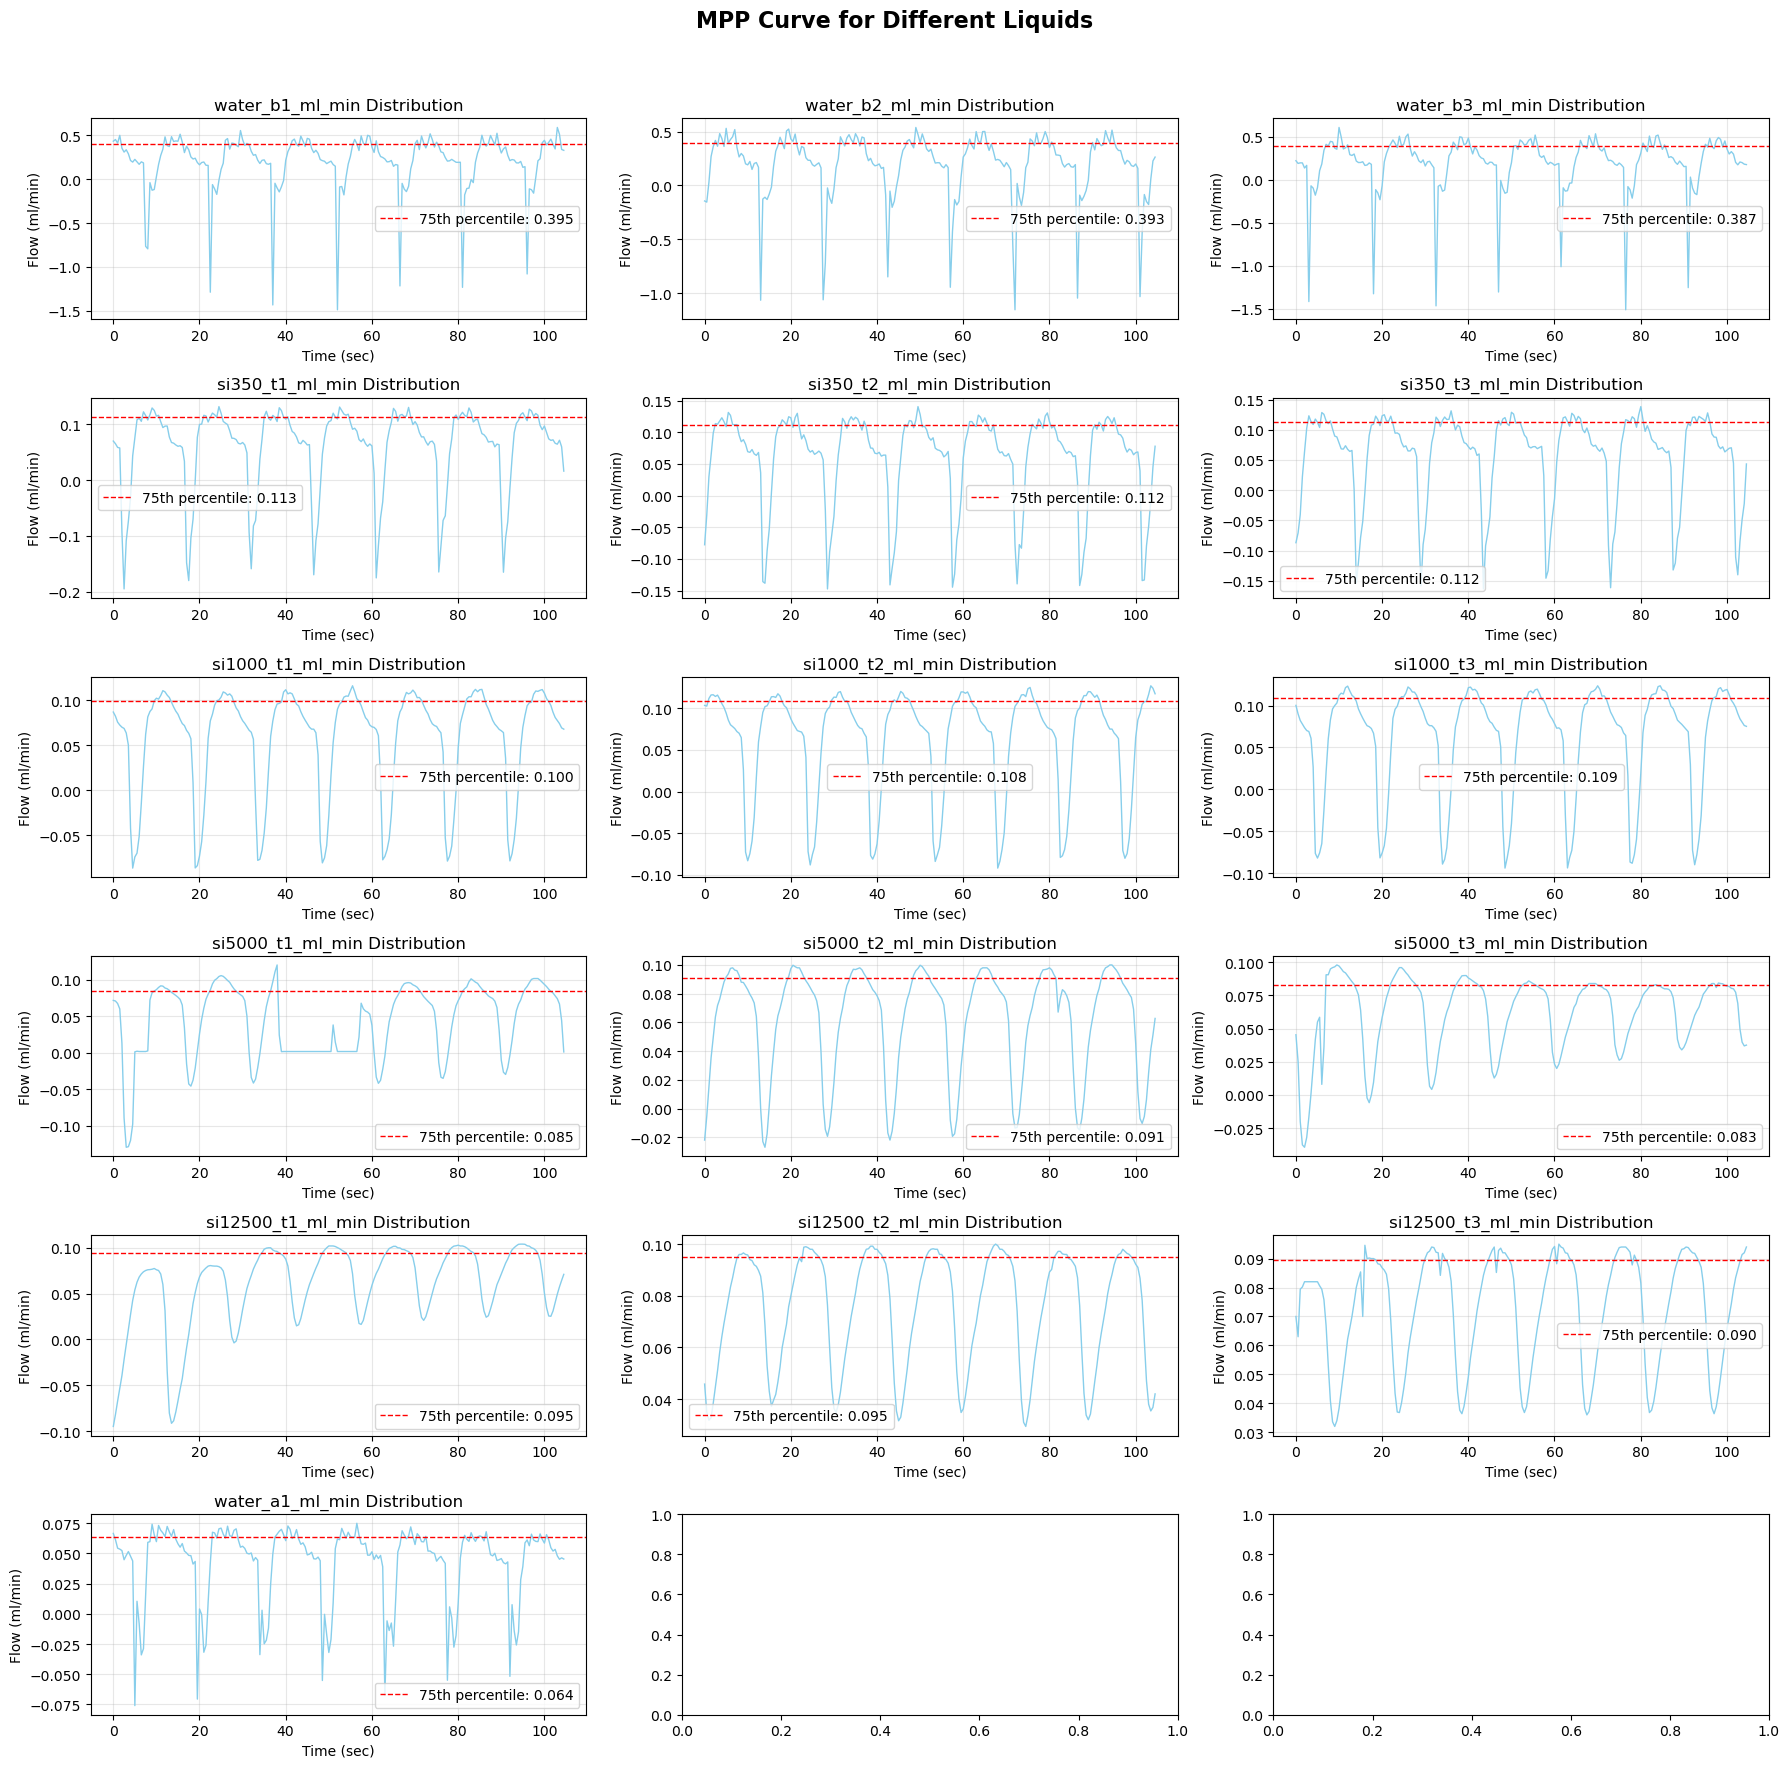

In [19]:
# Create visualizations for molecular descriptors
fig, axes = plt.subplots(6, 3, figsize=(18, 18))
fig.suptitle('MPP Curve for Different Liquids', fontsize=16, fontweight='bold')

# Define descriptors to plot
descriptors_to_plot = [
    'water_b1_ml_min', 'water_b2_ml_min', 'water_b3_ml_min',
    'si350_t1_ml_min', 'si350_t2_ml_min', 'si350_t3_ml_min',
    'si1000_t1_ml_min', 'si1000_t2_ml_min', 'si1000_t3_ml_min',
    'si5000_t1_ml_min', 'si5000_t2_ml_min', 'si5000_t3_ml_min',
    'si12500_t1_ml_min', 'si12500_t2_ml_min', 'si12500_t3_ml_min',
    'water_a1_ml_min'
]

for i, descriptor in enumerate(descriptors_to_plot):
    row = i // 3
    col = i % 3

    # Line plot (time vs descriptor)
    sns.lineplot(
        data=df, x='time_s', y=descriptor,
        ax=axes[row, col], color="skyblue", linewidth=1, errorbar=None
    )

    # Compute 75th percentile for this subset
    q75 = df[descriptor].quantile(0.75)

    # Add straight horizontal line at 75% value
    axes[row, col].axhline(y=q75, color='red', linestyle='--', linewidth=1,
                           label=f'75th percentile: {q75:.3f}')

    # Titles and labels
    axes[row, col].set_title(f'{descriptor} Distribution')
    axes[row, col].set_xlabel('Time (sec)')
    axes[row, col].set_ylabel('Flow (ml/min)')
    axes[row, col].grid(True, alpha=0.3)
    #axes[row, col].set_ylim(-0.3, 0.2)
    axes[row, col].legend()


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 3 - Cycle Detection